<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/NABIL(LOGISITiC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, classification_report,
                             confusion_matrix)



In [2]:

nabil=pd.read_csv("NABIL_clean.csv")
nabil["Date"] = pd.to_datetime(nabil["Date"])
nabil.head()
nabil.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            223 non-null    datetime64[ns]
 1   Open            223 non-null    float64       
 2   High            223 non-null    float64       
 3   Low             223 non-null    float64       
 4   Close           223 non-null    float64       
 5   Percent Change  223 non-null    float64       
 6   Volume          223 non-null    float64       
 7   Daily Return    222 non-null    float64       
 8   MA20            204 non-null    float64       
 9   MA50            174 non-null    float64       
 10  Volatility      203 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 19.3 KB


In [8]:
nabil["Next_Close"] = nabil["Close"].shift(-1)
nabil["Direction"] = (nabil["Next_Close"] > nabil["Close"]).astype(int)
features = ["Open", "High", "Low", "Volume", "MA20", "MA50"]
data = nabil.dropna(subset=features + ["Next_Close"]).reset_index(drop=True)
print(f"Usable rows: {len(data)} (out of {len(nabil)})")

Usable rows: 173 (out of 223)


In [15]:
X = data[features]
y_clf = data["Direction"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clf, test_size=0.2, shuffle=False
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
clf_model = LogisticRegression(class_weight="balanced")
clf_model.fit(X_train_scaled, y_train)
y_pred = clf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred,
                             target_names=["Down/Flat", "Up"]))


              precision    recall  f1-score   support

   Down/Flat       0.65      0.96      0.77        23
          Up       0.00      0.00      0.00        12

    accuracy                           0.63        35
   macro avg       0.32      0.48      0.39        35
weighted avg       0.43      0.63      0.51        35



Text(0.5, 1.0, 'NABIL Direction Prediction — Confusion Matrix')

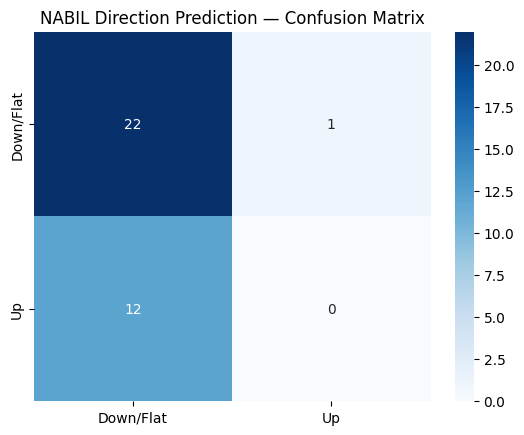

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Down/Flat","Up"], yticklabels=["Down/Flat","Up"])
plt.title("NABIL Direction Prediction — Confusion Matrix")
